# Color/Shape Final Data Preparation

Run the final Color/Shape loading, accuracy, and planned correct-trial RT-cleaning pipeline.

In [28]:
from pathlib import Path
import importlib
import sys

REPO_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
SRC_DIR = REPO_ROOT / "code" / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

import posthoc_analysis.color_shape as color_shape
color_shape = importlib.reload(color_shape)

print("Repository root:", REPO_ROOT)
print("Source directory:", SRC_DIR)

Repository root: /Users/hililbby/Library/Mobile Documents/com~apple~CloudDocs/UT Austin/JM/distractor_project/project_healthy/AI_Pd_analyzer/bci-posthoc-analysis
Source directory: /Users/hililbby/Library/Mobile Documents/com~apple~CloudDocs/UT Austin/JM/distractor_project/project_healthy/AI_Pd_analyzer/bci-posthoc-analysis/code/src


## Load, Annotate, and Compute Accuracy

Load the retained Color/Shape subjects, keep main-task rows only, add congruency and value-difference columns, and compute subject/session congruent and incongruent accuracy.

In [29]:
color_shape_results = color_shape.load_annotate_and_compute_color_shape_accuracy(
    save_outputs=True
)

color_shape_data = color_shape_results["data"]
color_shape_annotated = color_shape_results["annotated_data"]
color_shape_accuracy = color_shape_results["accuracy_summary"]
color_shape_loading_log = color_shape_results["loading_log"]
color_shape_mapping_log = color_shape_results["mapping_log"]

print("Loaded main-task rows:", color_shape_data.shape)
print("Annotated main-task rows:", color_shape_annotated.shape)
print("Accuracy summary:", color_shape_accuracy.shape)

Loaded Color/Shape subject/run mapping from: /Users/hililbby/Library/CloudStorage/Box-Box/CNBI/Attention_distraction/project_healthy/color_shape_task/subj_runs.csv
Mapping rows: 50 total, 25 valid, 4 excluded.
Group counts among valid rows:
group
control    13
bci        12


/Users/hililbby/Library/Mobile Documents/com~apple~CloudDocs/UT Austin/JM/distractor_project/project_healthy/AI_Pd_analyzer/bci-posthoc-analysis/code/src/posthoc_analysis/color_shape.py:132: UserWarning: Color/Shape loading: Documented mapping file subject_runs.csv was not found; using subj_runs.csv.
  f"Documented mapping file {documented_path.name} was not found; "
/Users/hililbby/Library/Mobile Documents/com~apple~CloudDocs/UT Austin/JM/distractor_project/project_healthy/AI_Pd_analyzer/bci-posthoc-analysis/code/src/posthoc_analysis/color_shape.py:230: UserWarning: Color/Shape loading: Found 21 malformed row(s) in subj_runs.csv; these rows will be skipped during run loading.
  f"Found {malformed_count} malformed row(s) in {mapping_path.name}; "
/Users/hililbby/Library/Mobile Documents/com~apple~CloudDocs/UT Austin/JM/distractor_project/project_healthy/AI_Pd_analyzer/bci-posthoc-analysis/code/src/posthoc_analysis/color_shape.py:235: UserWarning: Color/Shape loading: Found 4 excluded s

Color/Shape run loading status counts:
status
loaded       50
malformed    42
excluded      8
Loaded files: 50
Missing files: 0
Invalid-column files: 0
Cleaned trial count distribution across loaded runs:
count     50.0
mean     384.0
std        0.0
min      384.0
25%      384.0
50%      384.0
75%      384.0
max      384.0
Loaded task rows: 19,200
Subjects with loaded data: 25
Rows by group/session:
group    session
bci      post       4608
         pre        4608
control  post       4992
         pre        4992
Saved Color/Shape loading outputs:
  data: /Users/hililbby/Library/CloudStorage/Box-Box/CNBI/Attention_distraction/project_healthy/analyses/all_subjects_color_shape_loaded_trials.csv
  loading_log: /Users/hililbby/Library/CloudStorage/Box-Box/CNBI/Attention_distraction/project_healthy/analyses/color_shape_loading_log.csv
  mapping_log: /Users/hililbby/Library/CloudStorage/Box-Box/CNBI/Attention_distraction/project_healthy/analyses/color_shape_subject_runs_mapping_log.csv
Colo

## Loading Checks

Inspect retained/excluded subjects and final trial counts.

In [30]:
display(color_shape_loading_log["status"].value_counts(dropna=False).rename("n"))

display(
    color_shape_mapping_log.loc[
        color_shape_mapping_log["mapping_status"] == "excluded",
        ["subject_id", "group", "run1", "run2", "mapping_notes"],
    ]
)

display(
    color_shape_data.groupby(["group", "session"], dropna=False)
    .size()
    .rename("n_rows")
    .reset_index()
)

display(
    color_shape_annotated.groupby(["group", "session", "congruency"], dropna=False)
    .size()
    .rename("n_rows")
    .reset_index()
)

display(color_shape_annotated[["relevant_val_diff", "irrelevant_val_diff"]].describe())

status
loaded       50
malformed    42
excluded      8
Name: n, dtype: int64

,subject_id,group,run1,run2,mapping_notes
0,24,control,33.0,47.0,incomplete Color/Shape data: post run 47.csv l...
16,43,control,115.0,131.0,overall Color/Shape accuracy QC outlier: post ...
19,46,bci,116.0,136.0,overall Color/Shape accuracy QC outlier: post ...
28,55,bci,100.0,130.0,overall Color/Shape accuracy QC outlier: pre r...


,group,session,n_rows
0,bci,post,4608
1,bci,pre,4608
2,control,post,4992
3,control,pre,4992


,group,session,congruency,n_rows
0,bci,post,congruent,1728
1,bci,post,incongruent,2880
2,bci,pre,congruent,1728
3,bci,pre,incongruent,2880
4,control,post,congruent,1872
5,control,post,incongruent,3120
6,control,pre,congruent,1872
7,control,pre,incongruent,3120


,relevant_val_diff,irrelevant_val_diff
count,19200.000000,19200.000000
mean,1.666667,1.250000
std,0.745375,0.968271
min,1.000000,0.000000
25%,1.000000,0.750000
50%,1.500000,1.000000
75%,2.000000,2.000000
max,3.000000,3.000000


## Accuracy Summary

Accuracy uses all retained main-task trials and is summarized at the subject/session level.

In [31]:
display(color_shape_accuracy)

display(
    color_shape_accuracy.groupby(["group", "session"], dropna=False)[
        ["acc_congruent", "acc_incongruent"]
    ]
    .agg(["mean", "std", "count"])
)

,subject_id,group,session,run_number,n_trials_total,n_congruent_trials,n_incongruent_trials_irrelevant_gt0,acc_congruent,acc_incongruent
0,25,bci,post,75,384,144,144,0.979167,0.861111
1,25,bci,pre,66,384,144,144,0.944444,0.909722
2,26,bci,post,70,384,144,144,0.993056,0.937500
3,26,bci,pre,49,384,144,144,0.979167,0.958333
4,27,control,post,15,384,144,144,0.986111,0.902778
5,27,control,pre,6,384,144,144,0.986111,0.868056
6,29,bci,post,72,384,144,144,0.993056,0.854167
7,29,bci,pre,61,384,144,144,0.993056,0.965278
8,30,bci,post,38,384,144,144,0.986111,0.881944
9,30,bci,pre,8,384,144,144,1.000000,0.888889


acc_congruent                 acc_incongruent                
                         mean       std count            mean       std count
group   session                                                              
bci     post         0.971065  0.051274    12        0.849537  0.120766    12
        pre          0.950810  0.045437    12        0.851852  0.110293    12
control post         0.977030  0.025100    13        0.827991  0.106839    13
        pre          0.961538  0.030746    13        0.842415  0.086522    13

## Planned Correct-Trial RT Pipeline and Analysis Log

For RT analyses, keep correct response trials only, remove RT values below 150 ms, remove within-subject/session RT outliers using 3 MAD, compute congruent/incongruent RT, and create the subject/session analysis log.

Loaded Color/Shape subject/run mapping from: /Users/hililbby/Library/CloudStorage/Box-Box/CNBI/Attention_distraction/project_healthy/color_shape_task/subj_runs.csv
Mapping rows: 50 total, 25 valid, 4 excluded.
Group counts among valid rows:
group
control    13
bci        12


/Users/hililbby/Library/Mobile Documents/com~apple~CloudDocs/UT Austin/JM/distractor_project/project_healthy/AI_Pd_analyzer/bci-posthoc-analysis/code/src/posthoc_analysis/color_shape.py:132: UserWarning: Color/Shape loading: Documented mapping file subject_runs.csv was not found; using subj_runs.csv.
  f"Documented mapping file {documented_path.name} was not found; "
/Users/hililbby/Library/Mobile Documents/com~apple~CloudDocs/UT Austin/JM/distractor_project/project_healthy/AI_Pd_analyzer/bci-posthoc-analysis/code/src/posthoc_analysis/color_shape.py:230: UserWarning: Color/Shape loading: Found 21 malformed row(s) in subj_runs.csv; these rows will be skipped during run loading.
  f"Found {malformed_count} malformed row(s) in {mapping_path.name}; "
/Users/hililbby/Library/Mobile Documents/com~apple~CloudDocs/UT Austin/JM/distractor_project/project_healthy/AI_Pd_analyzer/bci-posthoc-analysis/code/src/posthoc_analysis/color_shape.py:235: UserWarning: Color/Shape loading: Found 4 excluded s

Color/Shape run loading status counts:
status
loaded       50
malformed    42
excluded      8
Loaded files: 50
Missing files: 0
Invalid-column files: 0
Cleaned trial count distribution across loaded runs:
count     50.0
mean     384.0
std        0.0
min      384.0
25%      384.0
50%      384.0
75%      384.0
max      384.0
Loaded task rows: 19,200
Subjects with loaded data: 25
Rows by group/session:
group    session
bci      post       4608
         pre        4608
control  post       4992
         pre        4992
Saved Color/Shape loading outputs:
  data: /Users/hililbby/Library/CloudStorage/Box-Box/CNBI/Attention_distraction/project_healthy/analyses/all_subjects_color_shape_loaded_trials.csv
  loading_log: /Users/hililbby/Library/CloudStorage/Box-Box/CNBI/Attention_distraction/project_healthy/analyses/color_shape_loading_log.csv
  mapping_log: /Users/hililbby/Library/CloudStorage/Box-Box/CNBI/Attention_distraction/project_healthy/analyses/color_shape_subject_runs_mapping_log.csv
Colo

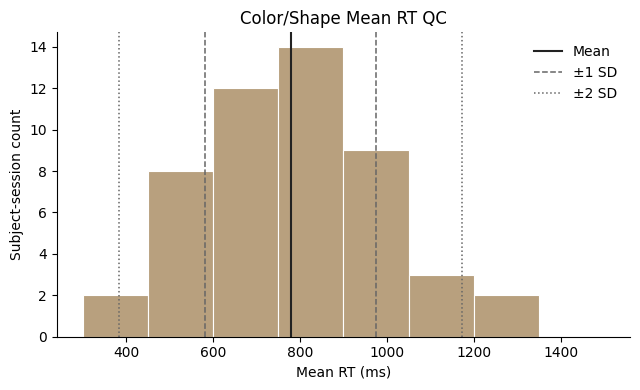

In [32]:
rt_results = color_shape.load_compute_color_shape_rt_and_analysis_log(
    save_outputs=True,
    min_rt_ms=150,
    mad_threshold=3,
    bin_width_ms=150,
)

color_shape_rt_planned_cleaned = rt_results["planned_rt_cleaned_data"]
color_shape_rt_low_rt_summary = rt_results["planned_rt_low_rt_summary"]
color_shape_rt_mad_summary = rt_results["planned_rt_mad_summary"]
color_shape_rt_overall_removal_summary = rt_results["planned_rt_overall_removal_summary"]
color_shape_rt_summary = rt_results["reaction_time_summary"]
color_shape_analysis_log = rt_results["analysis_log"]
color_shape_rt_planned_qc = rt_results["planned_rt_qc"]

print("Planned RT-cleaned trial table:", color_shape_rt_planned_cleaned.shape)
print("Reaction time summary:", color_shape_rt_summary.shape)
print("Analysis log:", color_shape_analysis_log.shape)
print("Saved figure:", rt_results["output_paths"]["planned_rt_qc_figure"])

## RT and Analysis Log Checks

Inspect trial removal percentages, final congruent/incongruent RT, and the combined analysis log.

In [33]:
display(
    color_shape_rt_low_rt_summary
    .assign(percent_low_rt_removed=lambda df: 100 * df["pct_low_rt_trials_removed_of_correct"])
    .sort_values("percent_low_rt_removed", ascending=False)
)

display(
    color_shape_rt_mad_summary
    .assign(percent_mad_removed=lambda df: 100 * df["pct_mad_rt_trials_removed_of_pre_mad"])
    .sort_values("percent_mad_removed", ascending=False)
)

display(
    color_shape_rt_overall_removal_summary
    .assign(percent_total_removed=lambda df: 100 * df["pct_total_trials_removed"])
    .sort_values("percent_total_removed", ascending=False)
)

display(color_shape_rt_summary)

display(color_shape_analysis_log)

display(color_shape_rt_planned_qc.sort_values("mean_rt_ms"))

,subject_id,group,session,run_number,n_correct_trials_before_low_rt,n_missing_rt_correct,min_rt_ms,n_low_rt_trials_removed,pct_low_rt_trials_removed_of_correct,pct_low_rt_trials_removed_of_all,percent_low_rt_removed
44,52,control,post,121,321,0,150,2,0.006231,0.005208,0.623053
24,40,control,post,132,325,0,150,1,0.003077,0.002604,0.307692
37,48,control,pre,87,367,0,150,0,0.000000,0.000000,0.000000
27,41,bci,pre,86,362,0,150,0,0.000000,0.000000,0.000000
28,42,control,post,139,324,0,150,0,0.000000,0.000000,0.000000
29,42,control,pre,129,335,0,150,0,0.000000,0.000000,0.000000
30,44,bci,post,118,374,0,150,0,0.000000,0.000000,0.000000
31,44,bci,pre,98,342,0,150,0,0.000000,0.000000,0.000000
32,45,control,post,110,373,0,150,0,0.000000,0.000000,0.000000
33,45,control,pre,105,377,0,150,0,0.000000,0.000000,0.000000


,subject_id,group,session,run_number,n_trials_before_mad,rt_median_before_mad_ms,rt_mad_before_mad_ms,rt_mad_lower_bound_ms,rt_mad_upper_bound_ms,mad_threshold,n_mad_rt_trials_removed,pct_mad_rt_trials_removed_of_pre_mad,pct_mad_rt_trials_removed_of_all,percent_mad_removed
35,47,control,pre,122,323,1351.0,535.0,-254.0,2956.0,3,92,0.284830,0.239583,28.482972
34,47,control,post,137,314,818.5,321.0,-144.5,1781.5,3,68,0.216561,0.177083,21.656051
24,40,control,post,132,324,611.0,168.0,107.0,1115.0,3,65,0.200617,0.169271,20.061728
39,49,bci,pre,102,346,707.5,202.5,100.0,1315.0,3,67,0.193642,0.174479,19.364162
29,42,control,pre,129,335,582.0,197.0,-9.0,1173.0,3,63,0.188060,0.164062,18.805970
5,27,control,pre,6,359,1000.0,363.0,-89.0,2089.0,3,66,0.183844,0.171875,18.384401
28,42,control,post,139,324,509.0,116.5,159.5,858.5,3,58,0.179012,0.151042,17.901235
38,49,bci,post,128,325,675.0,175.0,150.0,1200.0,3,54,0.166154,0.140625,16.615385
27,41,bci,pre,86,362,1230.5,517.5,-322.0,2783.0,3,58,0.160221,0.151042,16.022099
30,44,bci,post,118,374,641.5,141.0,218.5,1064.5,3,59,0.157754,0.153646,15.775401


,subject_id,group,session,run_number,n_total_trials,n_correct_trials,n_incorrect_trials_removed,pct_incorrect_trials_removed,n_missing_rt_correct_removed,pct_missing_rt_correct_removed,n_low_rt_trials_removed,pct_low_rt_trials_removed,n_mad_rt_trials_removed,pct_mad_rt_trials_removed,n_total_trials_removed,pct_total_trials_removed,n_trials_retained_for_rt,pct_trials_retained_for_rt,percent_total_removed
35,47,control,pre,122,384,323,61,0.158854,0,0.0,0,0.000000,92,0.239583,153,0.398438,231,0.601562,39.843750
34,47,control,post,137,384,314,70,0.182292,0,0.0,0,0.000000,68,0.177083,138,0.359375,246,0.640625,35.937500
22,39,bci,post,76,384,284,100,0.260417,0,0.0,0,0.000000,27,0.070312,127,0.330729,257,0.669271,33.072917
24,40,control,post,132,384,325,59,0.153646,0,0.0,1,0.002604,65,0.169271,125,0.325521,259,0.674479,32.552083
28,42,control,post,139,384,324,60,0.156250,0,0.0,0,0.000000,58,0.151042,118,0.307292,266,0.692708,30.729167
23,39,bci,pre,68,384,288,96,0.250000,0,0.0,0,0.000000,22,0.057292,118,0.307292,266,0.692708,30.729167
38,49,bci,post,128,384,325,59,0.153646,0,0.0,0,0.000000,54,0.140625,113,0.294271,271,0.705729,29.427083
29,42,control,pre,129,384,335,49,0.127604,0,0.0,0,0.000000,63,0.164062,112,0.291667,272,0.708333,29.166667
44,52,control,post,121,384,321,63,0.164062,0,0.0,2,0.005208,45,0.117188,110,0.286458,274,0.713542,28.645833
39,49,bci,pre,102,384,346,38,0.098958,0,0.0,0,0.000000,67,0.174479,105,0.273438,279,0.726562,27.343750


,subject_id,group,session,run_number,n_rt_cleaned_correct_trials,n_rt_congruent_correct_trials,n_rt_incongruent_correct_trials,rt_congruent_correct,rt_incongruent_correct
0,25,bci,post,75,315,127,101,619.937008,677.504950
1,25,bci,pre,66,310,116,112,707.163793,772.642857
2,26,bci,post,70,339,132,117,505.522727,545.401709
3,26,bci,pre,49,337,127,123,502.031496,552.691057
4,27,control,post,15,311,114,114,921.964912,923.464912
5,27,control,pre,6,293,115,102,928.278261,1026.196078
6,29,bci,post,72,318,129,106,837.875969,888.886792
7,29,bci,pre,61,332,125,123,1068.552000,1104.308943
8,30,bci,post,38,336,129,119,925.093023,1012.142857
9,30,bci,pre,8,332,134,114,965.970149,969.473684


,subject_id,group,session,run_number,n_valid_trials_used,n_main_task_trials_used,n_congruent_trials,n_incongruent_trials,acc_congruent,acc_incongruent,...,rt_incongruent_correct,n_rt_cleaned_correct_trials,n_rt_congruent_correct_trials,n_rt_incongruent_correct_trials,n_incorrect_trials_removed,n_low_rt_trials_removed,n_mad_rt_trials_removed,n_total_trials_removed,pct_total_trials_removed,n_trials_retained_for_rt
0,25,bci,post,75,384,384,144,144,0.979167,0.861111,...,677.504950,315,127,101,24,0,45,69,0.179688,315
1,25,bci,pre,66,384,384,144,144,0.944444,0.909722,...,772.642857,310,116,112,23,0,51,74,0.192708,310
2,26,bci,post,70,384,384,144,144,0.993056,0.937500,...,545.401709,339,132,117,11,0,34,45,0.117188,339
3,26,bci,pre,49,384,384,144,144,0.979167,0.958333,...,552.691057,337,127,123,10,0,37,47,0.122396,337
4,27,control,post,15,384,384,144,144,0.986111,0.902778,...,923.464912,311,114,114,19,0,54,73,0.190104,311
5,27,control,pre,6,384,384,144,144,0.986111,0.868056,...,1026.196078,293,115,102,25,0,66,91,0.236979,293
6,29,bci,post,72,384,384,144,144,0.993056,0.854167,...,888.886792,318,129,106,25,0,41,66,0.171875,318
7,29,bci,pre,61,384,384,144,144,0.993056,0.965278,...,1104.308943,332,125,123,10,0,42,52,0.135417,332
8,30,bci,post,38,384,384,144,144,0.986111,0.881944,...,1012.142857,336,129,119,22,0,26,48,0.125000,336
9,30,bci,pre,8,384,384,144,144,1.000000,0.888889,...,969.473684,332,134,114,21,0,31,52,0.135417,332


,subject_id,group,session,run_number,n_trials,n_nonmissing_rt,mean_rt_ms,median_rt_ms,sd_rt_ms,mean_rt_z,mean_rt_outlier_2sd
19,37,control,pre,27,284,284,390.179577,379.0,59.064074,-1.969535,False
18,37,control,post,39,303,303,406.722772,395.0,69.300400,-1.885585,False
28,42,control,post,139,266,266,507.815789,462.5,131.939294,-1.372582,False
22,39,bci,post,76,257,257,513.342412,497.0,83.637001,-1.344536,False
3,26,bci,pre,49,337,337,522.424332,500.0,152.641487,-1.298450,False
2,26,bci,post,70,339,339,525.050147,506.0,117.975077,-1.285125,False
25,40,control,pre,124,290,290,530.389655,510.0,121.804980,-1.258029,False
33,45,control,pre,105,333,333,559.672673,515.0,200.110386,-1.109430,False
32,45,control,post,110,330,330,569.630303,509.5,200.785228,-1.058900,False
29,42,control,pre,129,272,272,579.047794,509.0,215.526442,-1.011110,False


## Pre/Post Accuracy and RT Figure

Create the 2 × 2 pre/post figure for accuracy and RT by group and congruency, using subject-level bootstrap confidence intervals.

Color/Shape long summary:
Rows: 100
group    session  congruency 
bci      post     congruent      12
                  incongruent    12
         pre      congruent      12
                  incongruent    12
control  post     congruent      13
                  incongruent    13
         pre      congruent      13
                  incongruent    13
Color/Shape group-level summary:
  group session  congruency  accuracy_mean  accuracy_sd  accuracy_sem    rt_mean      rt_sd    rt_sem  n
    bci    post   congruent       0.971065     0.051274      0.014801 697.662039 150.718194 43.508595 12
    bci    post incongruent       0.849537     0.120766      0.034862 775.137255 187.829978 54.221844 12
    bci     pre   congruent       0.950810     0.045437      0.013117 853.493701 199.005164 57.447842 12
    bci     pre incongruent       0.851852     0.110293      0.031839 874.194162 181.106718 52.281006 12
control    post   congruent       0.977030     0.025100      0.006962 707.165500 156.815

,subject_id,group,session,run_number,congruency,accuracy,rt_correct
0,25,bci,post,75,congruent,0.979167,619.937008
1,25,bci,post,75,incongruent,0.861111,677.504950
2,25,bci,pre,66,congruent,0.944444,707.163793
3,25,bci,pre,66,incongruent,0.909722,772.642857
4,26,bci,post,70,congruent,0.993056,505.522727
...,...,...,...,...,...,...,...
95,53,control,pre,106,incongruent,0.805556,1020.194175
96,54,control,post,108,congruent,0.993056,829.227941
97,54,control,post,108,incongruent,0.888889,891.579832
98,54,control,pre,94,congruent,0.972222,829.779528


,group,session,congruency,accuracy_mean,accuracy_sd,accuracy_sem,rt_mean,rt_sd,rt_sem,n
0,bci,post,congruent,0.971065,0.051274,0.014801,697.662039,150.718194,43.508595,12
1,bci,post,incongruent,0.849537,0.120766,0.034862,775.137255,187.829978,54.221844,12
2,bci,pre,congruent,0.950810,0.045437,0.013117,853.493701,199.005164,57.447842,12
3,bci,pre,incongruent,0.851852,0.110293,0.031839,874.194162,181.106718,52.281006,12
4,control,post,congruent,0.977030,0.025100,0.006962,707.165500,156.815612,43.492825,13
5,control,post,incongruent,0.827991,0.106839,0.029632,754.827218,170.841381,47.382874,13
6,control,pre,congruent,0.961538,0.030746,0.008528,776.896579,243.720881,67.596010,13
7,control,pre,incongruent,0.842415,0.086522,0.023997,828.283296,254.441927,70.569493,13


Saved figure: /Users/hililbby/Library/Mobile Documents/com~apple~CloudDocs/UT Austin/JM/distractor_project/project_healthy/AI_Pd_analyzer/bci-posthoc-analysis/figures/color_shape_prepost_accuracy_rt_by_group.pdf


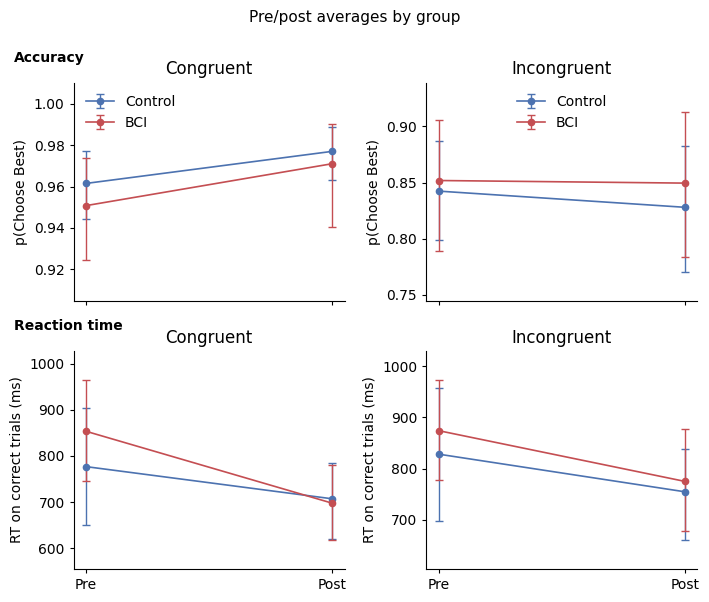

In [34]:
color_shape_summary_long = color_shape.create_color_shape_summary_long(
    color_shape_analysis_log
)
color_shape_group_summary = color_shape.summarize_color_shape_group_level(
    color_shape_summary_long
)
fig, axes, color_shape_prepost_figure_path = color_shape.plot_color_shape_prepost_accuracy_rt_by_group(
    color_shape_summary_long,
    n_boot=5000,
)

display(color_shape_summary_long)
display(color_shape_group_summary)
print("Saved figure:", color_shape_prepost_figure_path)

## Mixed ANOVAs

Run mixed ANOVAs separately for congruent and incongruent accuracy and RT.

In [35]:
color_shape_accuracy_anova = color_shape.run_color_shape_mixed_anova(
    color_shape_summary_long,
    dv="accuracy",
    label="accuracy",
)
color_shape_rt_anova = color_shape.run_color_shape_mixed_anova(
    color_shape_summary_long,
    dv="rt_correct",
    label="RT",
)

display(color_shape_accuracy_anova)
display(color_shape_rt_anova)

Prepared mixed ANOVA data for accuracy, congruent: 25 subjects, {'bci': 12, 'control': 13}.
Mixed ANOVA results for accuracy, congruent:
      dv congruency      Source  SS  DF1  DF2  MS        F    p-unc      np2                    method
accuracy  congruent       Group NaN    1   23 NaN 0.340454 0.565246 0.014586 fallback_2x2_t_equivalent
accuracy  congruent     Session NaN    1   24 NaN 7.989597 0.009334 0.249756 fallback_2x2_t_equivalent
accuracy  congruent Interaction NaN    1   23 NaN 0.138014 0.713664 0.005965 fallback_2x2_t_equivalent
Prepared mixed ANOVA data for accuracy, incongruent: 25 subjects, {'bci': 12, 'control': 13}.
Mixed ANOVA results for accuracy, incongruent:
      dv  congruency      Source  SS  DF1  DF2  MS        F    p-unc      np2                    method
accuracy incongruent       Group NaN    1   23 NaN 0.147249 0.704703 0.006361 fallback_2x2_t_equivalent
accuracy incongruent     Session NaN    1   24 NaN 0.414343 0.525877 0.016971 fallback_2x2_t_equivalen

/Users/hililbby/Library/Mobile Documents/com~apple~CloudDocs/UT Austin/JM/distractor_project/project_healthy/AI_Pd_analyzer/bci-posthoc-analysis/code/src/posthoc_analysis/color_shape.py:2533: UserWarning: Color/Shape loading: pingouin is not installed; using 2x2 t-equivalent fallback for Color/Shape accuracy mixed ANOVA. Original import error: No module named 'pingouin'.
/Users/hililbby/Library/Mobile Documents/com~apple~CloudDocs/UT Austin/JM/distractor_project/project_healthy/AI_Pd_analyzer/bci-posthoc-analysis/code/src/posthoc_analysis/color_shape.py:2533: UserWarning: Color/Shape loading: pingouin is not installed; using 2x2 t-equivalent fallback for Color/Shape RT mixed ANOVA. Original import error: No module named 'pingouin'.


,dv,congruency,Source,SS,DF1,DF2,MS,F,p-unc,np2,method
0,accuracy,congruent,Group,NaN,1,23,NaN,0.340454,0.565246,0.014586,fallback_2x2_t_equivalent
1,accuracy,congruent,Session,NaN,1,24,NaN,7.989597,0.009334,0.249756,fallback_2x2_t_equivalent
2,accuracy,congruent,Interaction,NaN,1,23,NaN,0.138014,0.713664,0.005965,fallback_2x2_t_equivalent
3,accuracy,incongruent,Group,NaN,1,23,NaN,0.147249,0.704703,0.006361,fallback_2x2_t_equivalent
4,accuracy,incongruent,Session,NaN,1,24,NaN,0.414343,0.525877,0.016971,fallback_2x2_t_equivalent
5,accuracy,incongruent,Interaction,NaN,1,23,NaN,0.197644,0.660785,0.008520,fallback_2x2_t_equivalent


,dv,congruency,Source,SS,DF1,DF2,MS,F,p-unc,np2,method
0,rt_correct,congruent,Group,NaN,1,23,NaN,0.216560,0.646050,0.009328,fallback_2x2_t_equivalent
1,rt_correct,congruent,Session,NaN,1,24,NaN,16.454416,0.000457,0.406740,fallback_2x2_t_equivalent
2,rt_correct,congruent,Interaction,NaN,1,23,NaN,2.636829,0.118039,0.102853,fallback_2x2_t_equivalent
3,rt_correct,incongruent,Group,NaN,1,23,NaN,0.187985,0.668638,0.008107,fallback_2x2_t_equivalent
4,rt_correct,incongruent,Session,NaN,1,24,NaN,10.807781,0.003105,0.310499,fallback_2x2_t_equivalent
5,rt_correct,incongruent,Interaction,NaN,1,23,NaN,0.232791,0.634022,0.010020,fallback_2x2_t_equivalent
